<a href="https://www.kaggle.com/code/sonawanelalitsunil/uk-road-traffic-accident-data-ml-85-50?scriptVersionId=250768185" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/road-accidents-dataset/Road Accident Data.csv


## Title :
🚧 UK Road Traffic Accident Data

## Description:
This dataset contains comprehensive information on road traffic accidents in the United Kingdom. It includes data on the location, date, severity, and type of accidents, as well as details about the vehicles and casualties involved. The dataset is valuable for analyzing trends in traffic incidents, identifying high-risk areas, evaluating the impact of road safety measures, and building predictive models to enhance traffic management and public safety initiatives.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/road-accidents-dataset/Road Accident Data.csv')

In [3]:
df.head()

,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,BS0000001,01-01-2021,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,BS0000002,05-01-2021,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,BS0000003,04-01-2021,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,BS0000004,05-01-2021,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,08:10,Urban,Other,Motorcycle over 500cc
4,BS0000005,06-01-2021,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [4]:
df.tail()

,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
307968,BS0307969,18-02-2022,Thursday,Data missing or out of range,Not at junction or within 20 metres,Slight,57.374005,Daylight,Highland,NaN,...,2,1,Northern,Dry,Single carriageway,60,07:00,Rural,Fine no high winds,Car
307969,BS0307970,21-02-2022,Sunday,Data missing or out of range,Not at junction or within 20 metres,Slight,57.232273,Darkness - no lighting,Highland,NaN,...,1,1,Northern,Frost or ice,Single carriageway,60,03:00,Rural,Fine no high winds,Car
307970,BS0307971,23-02-2022,Tuesday,Give way or uncontrolled,T or staggered junction,Slight,57.585044,Daylight,Highland,NaN,...,1,3,Northern,Frost or ice,Single carriageway,30,09:38,Rural,Fine no high winds,Car
307971,BS0307972,23-02-2022,Tuesday,Give way or uncontrolled,T or staggered junction,Serious,57.214898,Darkness - no lighting,Highland,NaN,...,1,2,Northern,Wet or damp,Single carriageway,60,18:25,Rural,Fine no high winds,Motorcycle over 500cc
307972,BS0307973,28-02-2022,Sunday,Give way or uncontrolled,T or staggered junction,Serious,57.575210,Daylight,Highland,Other object on road,...,1,1,Northern,Wet or damp,Dual carriageway,60,15:45,Rural,Snowing no high winds,Car


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Accident_Index              307973 non-null  object 
 1   Accident Date               307973 non-null  object 
 2   Day_of_Week                 307973 non-null  object 
 3   Junction_Control            307973 non-null  object 
 4   Junction_Detail             307973 non-null  object 
 5   Accident_Severity           307973 non-null  object 
 6   Latitude                    307973 non-null  float64
 7   Light_Conditions            307973 non-null  object 
 8   Local_Authority_(District)  307973 non-null  object 
 9   Carriageway_Hazards         5424 non-null    object 
 10  Longitude                   307973 non-null  float64
 11  Number_of_Casualties        307973 non-null  int64  
 12  Number_of_Vehicles          307973 non-null  int64  
 13  Police_Force  

In [6]:
df.describe()

,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles,Speed_limit
count,307973.000000,307973.000000,307973.000000,307973.000000,307973.000000
mean,52.487005,-1.368884,1.356882,1.829063,38.866037
std,1.339011,1.356092,0.815857,0.710477,14.032933
min,49.914488,-7.516225,1.000000,1.000000,10.000000
25%,51.485248,-2.247937,1.000000,1.000000,30.000000
50%,52.225943,-1.349258,1.000000,2.000000,30.000000
75%,53.415517,-0.206810,1.000000,2.000000,50.000000
max,60.598055,1.759398,48.000000,32.000000,70.000000


In [7]:
df.dtypes

Accident_Index                 object
Accident Date                  object
Day_of_Week                    object
Junction_Control               object
Junction_Detail                object
Accident_Severity              object
Latitude                      float64
Light_Conditions               object
Local_Authority_(District)     object
Carriageway_Hazards            object
Longitude                     float64
Number_of_Casualties            int64
Number_of_Vehicles              int64
Police_Force                   object
Road_Surface_Conditions        object
Road_Type                      object
Speed_limit                     int64
Time                           object
Urban_or_Rural_Area            object
Weather_Conditions             object
Vehicle_Type                   object
dtype: object

In [8]:
df.shape

(307973, 21)

In [9]:
df.isnull().sum()

Accident_Index                     0
Accident Date                      0
Day_of_Week                        0
Junction_Control                   0
Junction_Detail                    0
Accident_Severity                  0
Latitude                           0
Light_Conditions                   0
Local_Authority_(District)         0
Carriageway_Hazards           302549
Longitude                          0
Number_of_Casualties               0
Number_of_Vehicles                 0
Police_Force                       0
Road_Surface_Conditions            0
Road_Type                          0
Speed_limit                        0
Time                              17
Urban_or_Rural_Area                0
Weather_Conditions                 0
Vehicle_Type                       0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['Accident_Index', 'Accident Date', 'Day_of_Week', 'Junction_Control',
       'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Carriageway_Hazards', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time',
       'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type'],
      dtype='object')

## Data visualizations

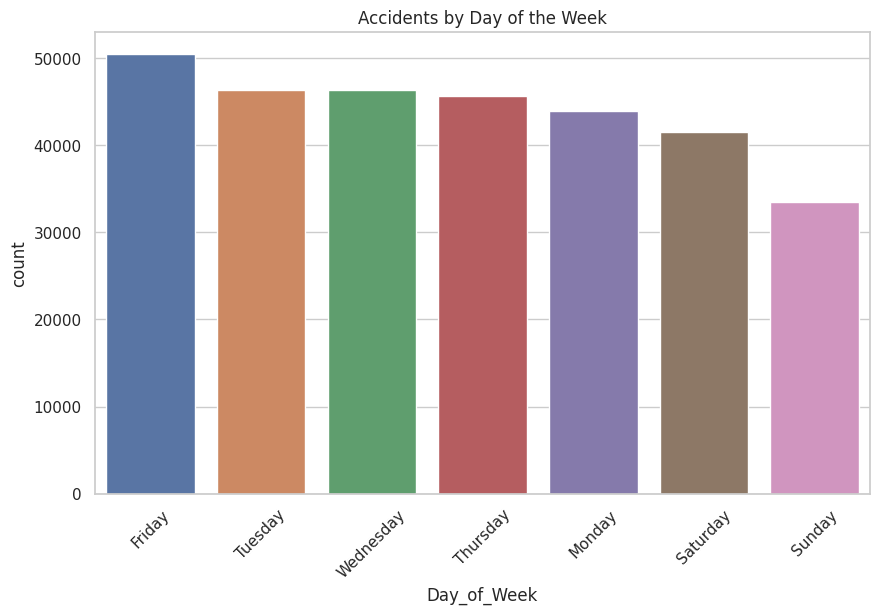

In [12]:
# --- Initial Data Cleaning ---
df['Accident Date'] = pd.to_datetime(df['Accident Date'], errors='coerce')
df['Hour'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour

# --- Set Style ---
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# --- 1. Accidents by Day of Week ---
sns.countplot(data=df, x='Day_of_Week', order=df['Day_of_Week'].value_counts().index)
plt.title('Accidents by Day of the Week')
plt.xticks(rotation=45)
plt.show()

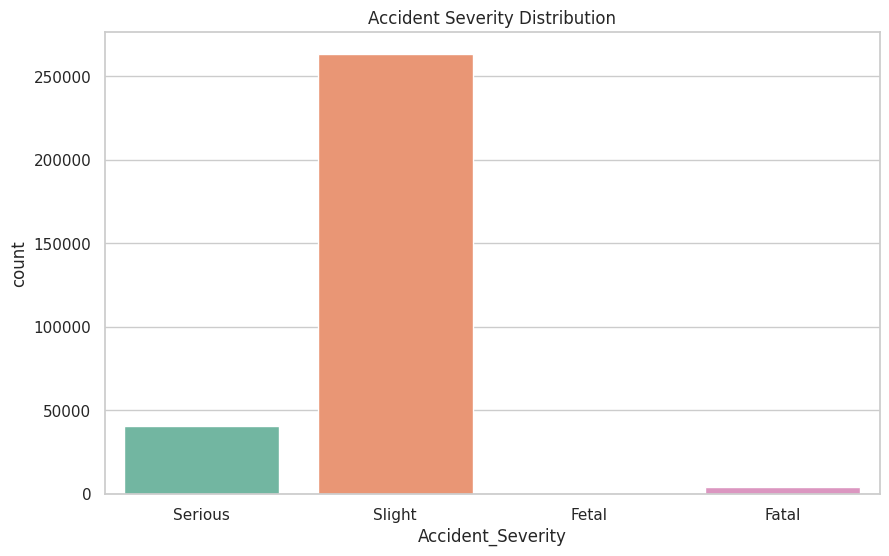

In [13]:
# --- 2. Accident Severity Distribution ---
sns.countplot(data=df, x='Accident_Severity', palette='Set2')
plt.title('Accident Severity Distribution')
plt.show()


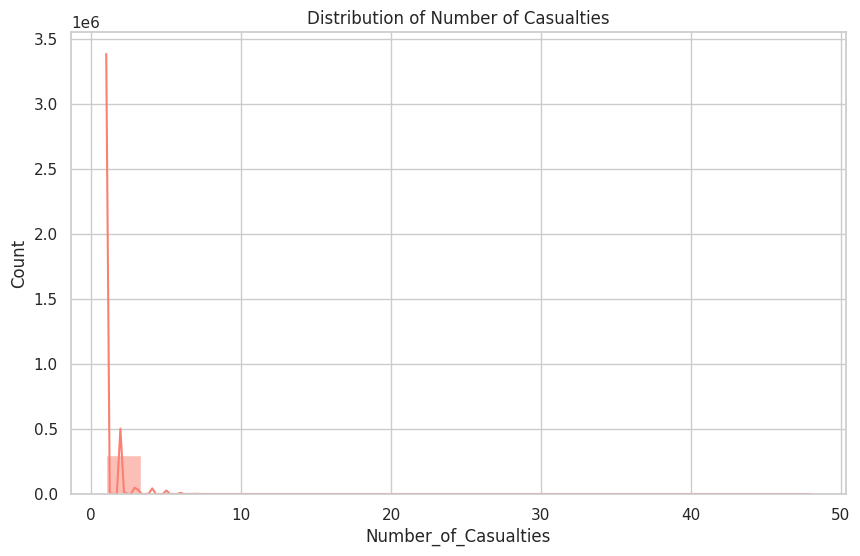

In [14]:
# --- 3. Number of Casualties Distribution ---
sns.histplot(df['Number_of_Casualties'], kde=True, bins=20, color='salmon')
plt.title('Distribution of Number of Casualties')
plt.show()

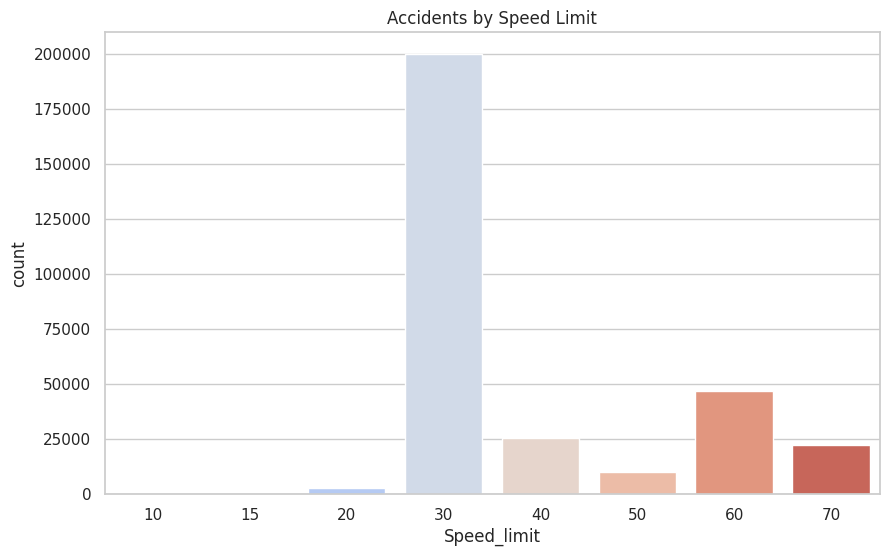

In [15]:
# --- 4. Accidents by Speed Limit ---
sns.countplot(data=df, x='Speed_limit', palette='coolwarm')
plt.title('Accidents by Speed Limit')
plt.show()

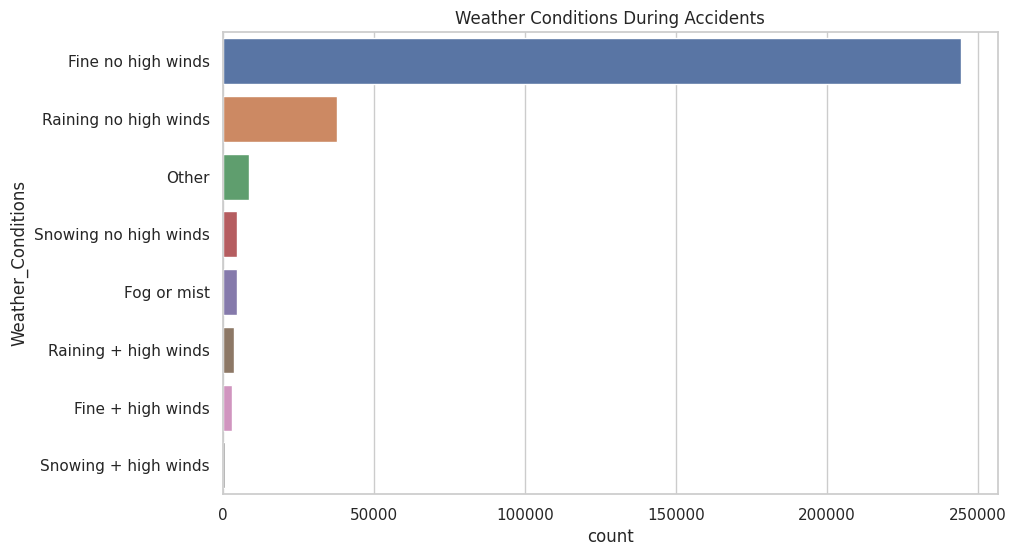

In [16]:
# --- 5. Weather Conditions During Accidents ---
sns.countplot(data=df, y='Weather_Conditions', order=df['Weather_Conditions'].value_counts().index)
plt.title('Weather Conditions During Accidents')
plt.show()

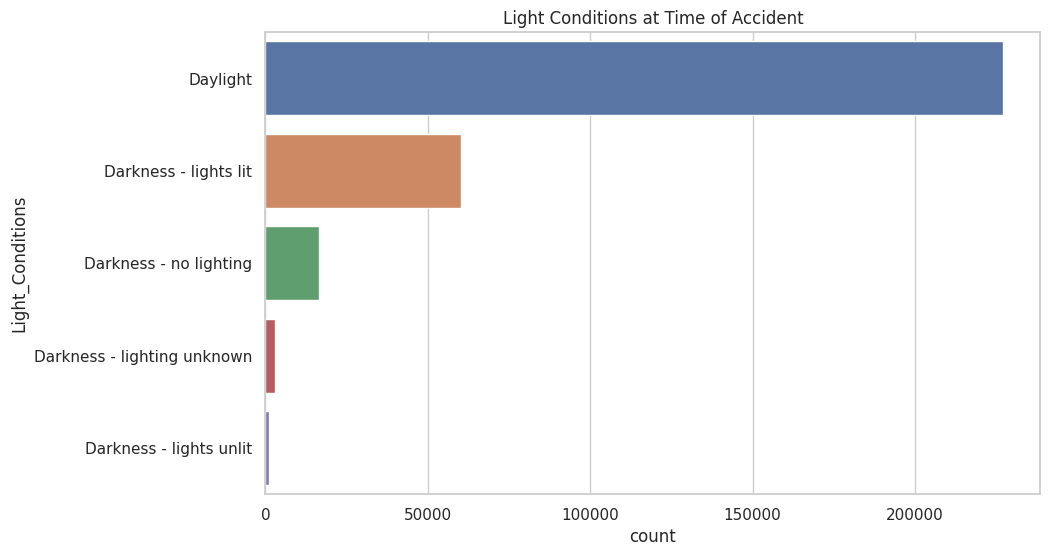

In [17]:
# --- 6. Light Conditions ---
sns.countplot(data=df, y='Light_Conditions', order=df['Light_Conditions'].value_counts().index)
plt.title('Light Conditions at Time of Accident')
plt.show()

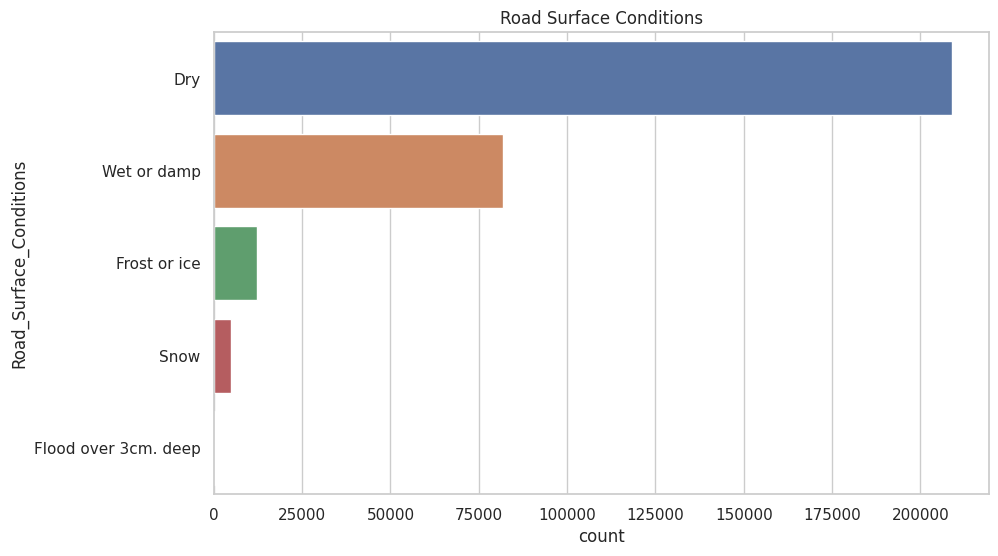

In [18]:
# --- 7. Road Surface Conditions ---
sns.countplot(data=df, y='Road_Surface_Conditions', order=df['Road_Surface_Conditions'].value_counts().index)
plt.title('Road Surface Conditions')
plt.show()


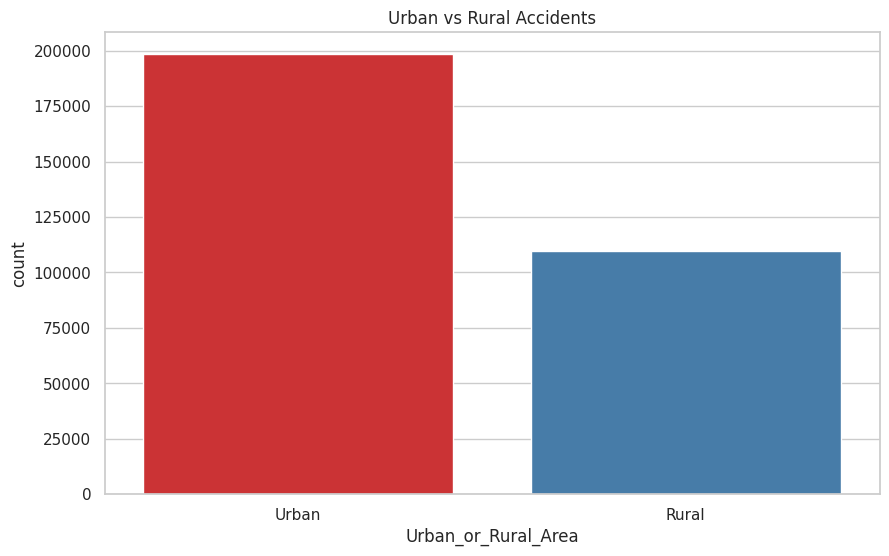

In [19]:
# --- 8. Urban vs Rural Area ---
sns.countplot(data=df, x='Urban_or_Rural_Area', palette='Set1')
plt.title('Urban vs Rural Accidents')
plt.show()

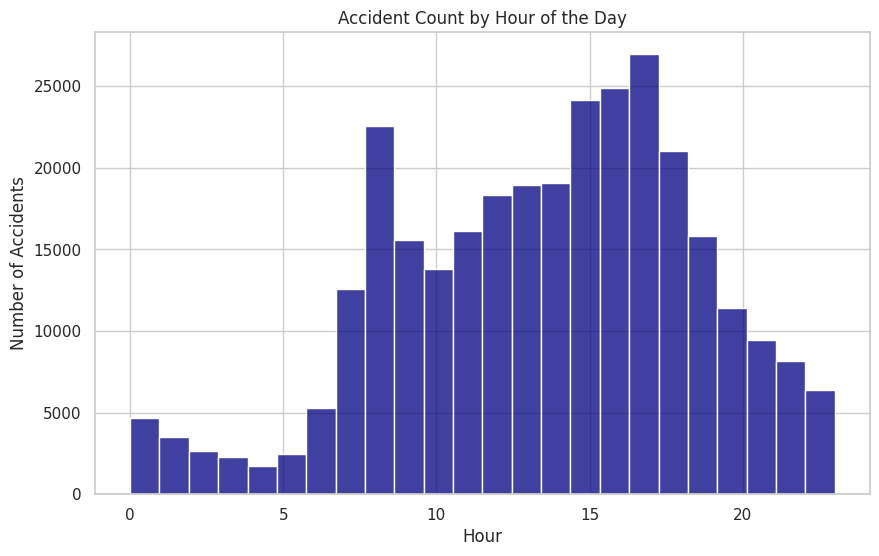

In [20]:
# --- 9. Accidents by Hour ---
sns.histplot(df['Hour'].dropna(), bins=24, kde=False, color='navy')
plt.title('Accident Count by Hour of the Day')
plt.xlabel('Hour')
plt.ylabel('Number of Accidents')
plt.show()

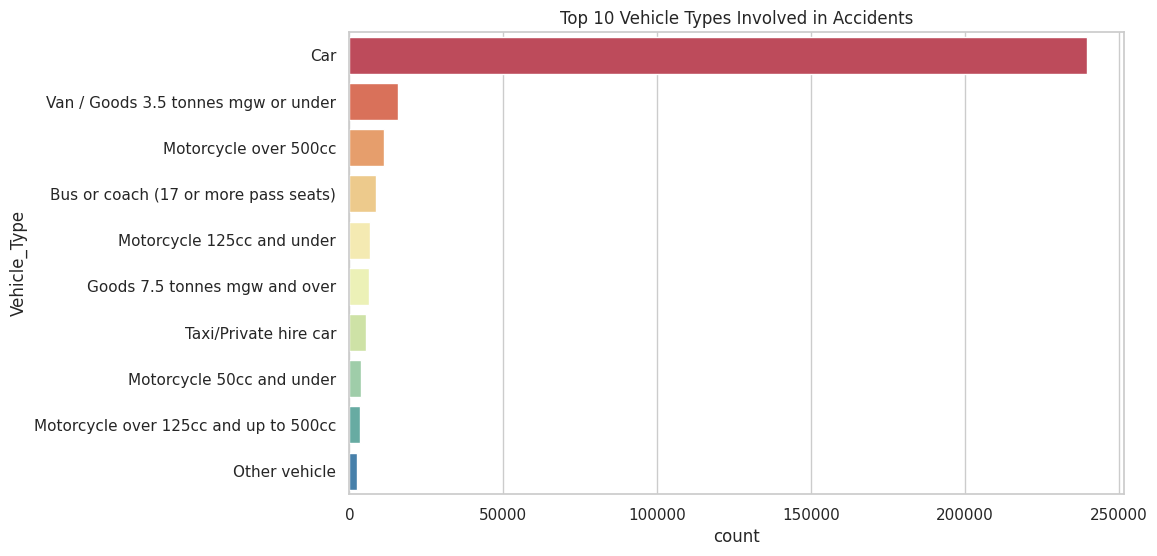

In [21]:
# --- 10. Vehicle Type Involved ---
top_vehicles = df['Vehicle_Type'].value_counts().nlargest(10).index
sns.countplot(data=df[df['Vehicle_Type'].isin(top_vehicles)], y='Vehicle_Type', order=top_vehicles, palette='Spectral')
plt.title('Top 10 Vehicle Types Involved in Accidents')
plt.show()

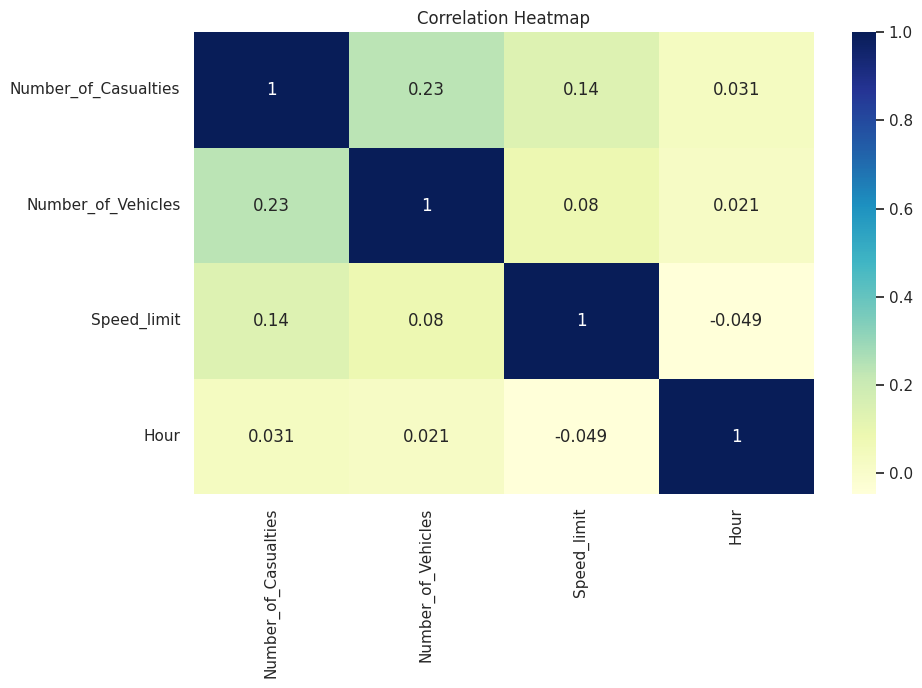

In [22]:
# --- 11. Heatmap for Numeric Correlation ---
numeric_cols = ['Number_of_Casualties', 'Number_of_Vehicles', 'Speed_limit', 'Hour']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()

In [23]:
import plotly.express as px

In [24]:
# --- 12. Optional: Map-based Accident Distribution ---
if df[['Latitude', 'Longitude']].dropna().shape[0] > 0:
    fig = px.scatter_mapbox(
        df.dropna(subset=['Latitude', 'Longitude']).sample(1000),  # Sample to reduce rendering time
        lat="Latitude", lon="Longitude",
        color="Accident_Severity",
        mapbox_style="carto-positron",
        zoom=5,
        title="Accident Locations in the UK"
    )
    fig.show()

## predictive modeling

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [26]:
# Drop rows with missing target
df = df.dropna(subset=['Accident_Severity'])

# Fill missing values for time and convert to hour
df['Hour'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour

# Drop high-cardinality or location-based columns not useful for ML
drop_cols = ['Accident_Index', 'Accident Date', 'Time', 'Latitude', 'Longitude']
df = df.drop(columns=drop_cols)

# Label Encoding for categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = df[col].astype(str)  # ensure all entries are string
    df[col] = le.fit_transform(df[col])

# Fill remaining missing numeric values
imputer = SimpleImputer(strategy='mean')
df[df.columns] = imputer.fit_transform(df)


In [27]:
# Features and target
X = df.drop(columns=['Accident_Severity'])
y = df['Accident_Severity']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Support Vector Machine": SVC(),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Train and evaluate
print("Model Accuracy (%):")
print("--------------------")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: {acc * 100:.2f}%")

Model Accuracy (%):
--------------------
Logistic Regression: 85.49%
Decision Tree: 73.73%
Random Forest: 84.48%
Gradient Boosting: 85.50%
Support Vector Machine: 85.50%
Naive Bayes: 36.67%
K-Nearest Neighbors: 83.52%


## Thank you..pls upvote!!
